# 머신러닝 회귀모델 실습

---

## 실습 목표
- 머신러닝 다양한 모델을 활용하여 회귀분석을 진행해봅니다.
---

## 실습 목차




-  **회귀분석 실습** : **LinearRegression, KNN, SVM, AdaBoost, Bagging, RandomForest** 등 다양한 모델을 구현하는 실습을 진행해봅니다.


---

### 데이터 및 라이브러리 불러오기

In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached joblib-1.5.1-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 19.1 MB/s eta 0:00:00a 0:00:01
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 57.3 MB/s eta 0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 44.2 MB/s eta 0:00:00
Using cached joblib-1.5.1-py3-none-any.whl (307 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 59.3 MB/s eta 0:00:00a 0:00:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [seaborn]8/10 [matplotlib]n]


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split

전처리 완료한 데이터를 불러옵니다.

**InkjetDB_preprocessing.csv 설명**

Unnamed: 0,Viscosity,Velocity,PrintingSpeed 총 4개의 Feature를 이용해서 
PatternSize의 값을 회귀예측

In [3]:
data_dir = './'
df = pd.read_csv(os.path.join(data_dir, 'InkjetDB_preprocessing.csv'))

X = df.drop(['PatternSize'], axis=1)
y = df['PatternSize']

## 회귀분석 실습

### 학습 및 테스트 데이터세트 분리

---

In [4]:
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state = 1)
X.shape
print('학습 데이터 :' ,X_train.shape)
print('테스트 데이터 : ', X_test.shape)

학습 데이터 : (180, 4)
테스트 데이터 :  (45, 4)


### 선형 회귀(Linear Regression)

---

먼저 선형회귀를 이용해 회귀분석을 진행해보겠습니다. 평가지표는 결정계수와 평균제곱근오차(RMSE)를 사용합니다. 

- **결정계수 ($R^2$)** : 독립 변수가 종속 변수를 얼마나 잘 설명해주는지 보여주는 지표입니다
- **평균제곱근오차** : 추정 값 또는 모델이 예측한 값과 실제 환경에서 관찰되는 값의 차이를 다룰 때 흔히 사용하는 측도로 정밀도(precision)를 표현하는데 적합 각각의 차이값은 잔차(residual)라고도 하며, 평균 제곱근 편차는 잔차들을 하나의 측도로 종합할 때 사용합니다.

- X가 Y와의 상관관계가 클수록 $R^2$의 값은 1에 가까워집니다.
- ($R^2$≥0.65)정도가 되어야 의미있는 회귀식으로 볼 수 있습니다.

#### 기본 회귀 모델 학습 - 선형 회귀 모델

선형 회귀 모델을 학습시켜보겠습니다.

In [5]:
# TODO: langchain을 통해 생성된 코드 입력 (필요시 수정)
# Langchain이 생성한 코드 중 X_train, y_train, X_test, y_test 변수에 새로운 값을 할당하는 코드는 입력하지 말아주세요
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# 선형 회귀 모델 정의
model = LinearRegression()

# 모델 학습
model.fit(X_train, y_train)

# 예측
y_pred = model.predict(X_test)

# 결정 계수 계산
r2 = r2_score(y_test, y_pred)

# 평균 제곱근 오차 계산
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("결정 계수:", r2)
print("평균 제곱근 오차:", rmse)

결정 계수: 0.5737449375648542
평균 제곱근 오차: 51.76703385093582


평가를 마친 이후, 시각화 코드를 통해 실제값과 예측값의 차이를 확인해봅시다. 

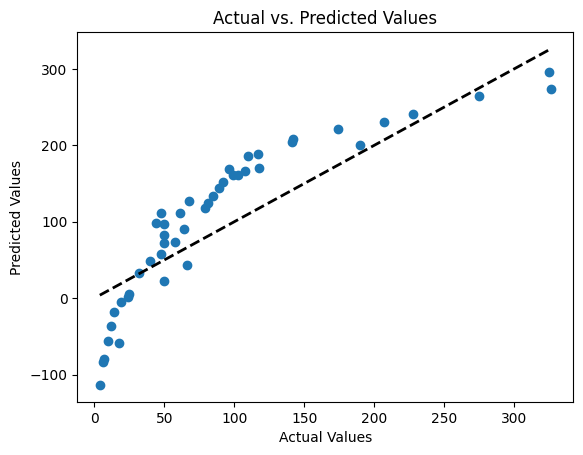

In [6]:
# TODO: langchain을 통해 생성된 코드 입력 (필요시 수정)
# Langchain이 생성한 코드 중 X_train, y_train, X_test, y_test 변수에 새로운 값을 할당하는 코드는 입력하지 말아주세요
import numpy as np
import matplotlib.pyplot as plt

# 모델의 출력값
y_pred = model.predict(X_test)

# 그래프로 시각화
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', lw=2)  # 일치하는 직선
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.show()

### KNN(K-최근접 이웃)

---

**KNN Regressor** : 주변의 가장 가까운 K개의 샘플을 통해 값을 예측하는 방식 입니다.


#### 회귀 모델 학습 - KNN Regressor

 KNN 회귀 모델을 학습시켜보겠습니다. 데이터의 변수명이 저희가 정의한 변수명과 다를 경우, 이를 조절해줍시다.

In [7]:
# TODO: langchain을 통해 생성된 코드 입력 (필요시 수정)
# Langchain이 생성한 코드 중 X_train, y_train, X_test, y_test 변수에 새로운 값을 할당하는 코드는 입력하지 말아주세요
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error

# KNN 회귀 모델 정의
knn = KNeighborsRegressor()

# 모델 학습
knn.fit(X_train, y_train)

# 예측
y_pred = knn.predict(X_test)

# 결정 계수 계산
r2 = r2_score(y_test, y_pred)

# 평균 제곱근 오차 계산
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("결정 계수:", r2)
print("평균 제곱근 오차:", rmse)

결정 계수: -0.45114177330805294
평균 제곱근 오차: 95.51540655249754


평가를 마친 이후, 시각화 코드를 통해 실제값과 예측값의 차이를 확인해봅시다. 

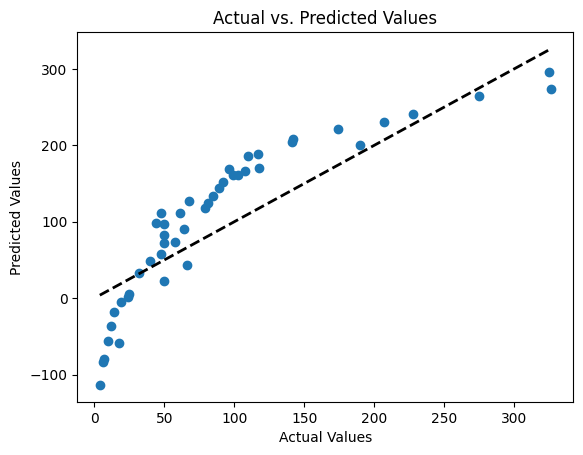

In [8]:
# TODO: langchain을 통해 생성된 코드 입력 (필요시 수정)
# Langchain이 생성한 코드 중 X_train, y_train, X_test, y_test 변수에 새로운 값을 할당하는 코드는 입력하지 말아주세요
import numpy as np
import matplotlib.pyplot as plt

# 모델의 출력값
y_pred = model.predict(X_test)

# 그래프로 시각화
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', lw=2)  # 일치하는 직선
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.show()

### 서포트벡터머신(SVM)

--- 

**서포트벡터머신(SVM)** : 주어진 데이터 집합을 바탕으로 하여 새로운 데이터가 어느 카테고리에 속할지 판단하는 비확률적 이진 선형 분류 모델을 만드며, 만들어진 분류 모델은 데이터가 사상된 공간에서 경계로 표현되는데 SVM 알고리즘은 그 중 가장 큰 폭을 가진 경계를 찾는 방식입니다.

- **kernel** : 선형 커널
- **C** : 학습 오류에 대한 패널티, C 값이 클 수록 모델이 학습 데이터에 좀 더 최적화 됨, 너무 크면 오버피팅 발생
- **Epsilon** : 임계값, 예측한 값이 GT 범위 안에 있으면 패널티 부여 X

#### 회귀 모델 학습 - SVM

SVN을 학습시켜보겠습니다.

In [9]:
# TODO: langchain을 통해 생성된 코드 입력 (필요시 수정)
# Langchain이 생성한 코드 중 X_train, y_train, X_test, y_test 변수에 새로운 값을 할당하는 코드는 입력하지 말아주세요
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# SVM 회귀 모델 정의
svm_regressor = SVR()

# 모델 학습
svm_regressor.fit(X_train, y_train)

# 예측
y_pred = svm_regressor.predict(X_test)

# 결정 계수 계산
r2 = r2_score(y_test, y_pred)

# 평균 제곱근 오차 계산
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("결정 계수: ", r2)
print("평균 제곱근 오차: ", rmse)

결정 계수:  -0.03136053271001882
평균 제곱근 오차:  80.5237071230051


평가를 마친 이후, 시각화 코드를 통해 실제값과 예측값의 차이를 확인해봅시다.

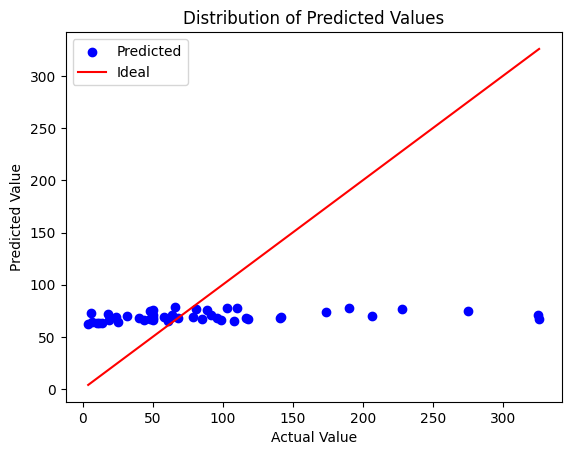

In [10]:
# TODO: langchain을 통해 생성된 코드 입력 (필요시 수정)
# Langchain이 생성한 코드 중 X_train, y_train, X_test, y_test 변수에 새로운 값을 할당하는 코드는 입력하지 말아주세요
# 그래프 그리기
plt.scatter(y_test, y_pred, color='blue', label='Predicted')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', label='Ideal')
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.title('Distribution of Predicted Values')
plt.legend()
plt.show()

### AdaBoost(Adaptive Boost)

---

**Adaptive Boost** : Adaptive + Boosting 로 만들어진 단어로 약한 분류기(weak classifier)들이 상호보완 하도록 순차적(sequential)으로 학습하고, 이들을 조합하여 최종적으로 강한 분류기(strong classifier)의 성능을 향상시키는 것

#### 회귀 모델 학습 - AdaBoost

Chain이 생성한 코드를 사용해서 선형 회귀 모델을 학습시켜보겠습니다. 데이터의 변수명이 저희가 정의한 변수명과 다를 경우, 이를 조절해줍시다.

In [11]:
# TODO: langchain을 통해 생성된 코드 입력 (필요시 수정)
# Langchain이 생성한 코드 중 X_train, y_train, X_test, y_test 변수에 새로운 값을 할당하는 코드는 입력하지 말아주세요
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import r2_score, mean_squared_error

# AdaBoost 회귀 모델 정의
model = AdaBoostRegressor()

# 모델 학습
model.fit(X_train, y_train)

# 테스트 데이터에 대한 예측
y_pred = model.predict(X_test)

# 결정 계수 계산
r2 = r2_score(y_test, y_pred)

# 평균 제곱근 오차 계산
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("결정 계수:", r2)
print("평균 제곱근 오차:", rmse)

결정 계수: 0.8771636920124305
평균 제곱근 오차: 27.789573649046346


평가를 마친 이후, 시각화 코드를 통해 실제값과 예측값의 차이를 확인해봅시다. 

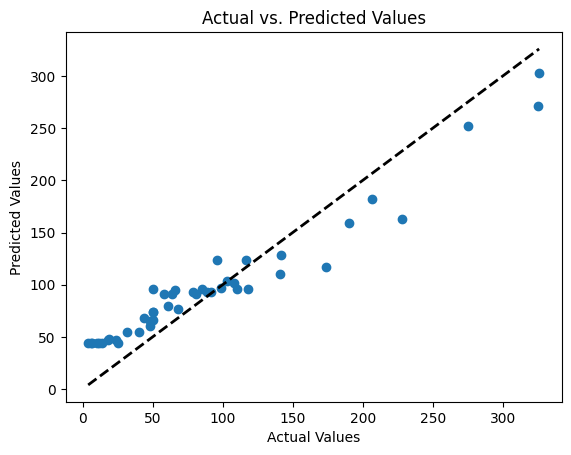

In [12]:
# TODO: langchain을 통해 생성된 코드 입력 (필요시 수정)
# Langchain이 생성한 코드 중 X_train, y_train, X_test, y_test 변수에 새로운 값을 할당하는 코드는 입력하지 말아주세요
import numpy as np
import matplotlib.pyplot as plt

# 모델의 출력값
y_pred = model.predict(X_test)

# 그래프로 시각화
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', lw=2)  # 일치하는 직선
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.show()

### Bagging

---

#### 회귀 모델 학습 - bagging

Bagging 모델을 학습시켜보겠습니다. 

In [13]:
# TODO: langchain을 통해 생성된 코드 입력 (필요시 수정)
# Langchain이 생성한 코드 중 X_train, y_train, X_test, y_test 변수에 새로운 값을 할당하는 코드는 입력하지 말아주세요
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Bagging 회귀 모델 정의
bagging_model = BaggingRegressor()

# 모델 학습
bagging_model.fit(X_train, y_train)

# 테스트 데이터에 대한 예측
y_pred = bagging_model.predict(X_test)

# 결정 계수 계산
r2 = r2_score(y_test, y_pred)

# 평균 제곱근 오차 계산
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("결정 계수:", r2)
print("평균 제곱근 오차:", rmse)

결정 계수: 0.924720760041681
평균 제곱근 오차: 21.754851310812388


평가를 마친 이후, 시각화 코드를 통해 실제값과 예측값의 차이를 확인해봅시다. 

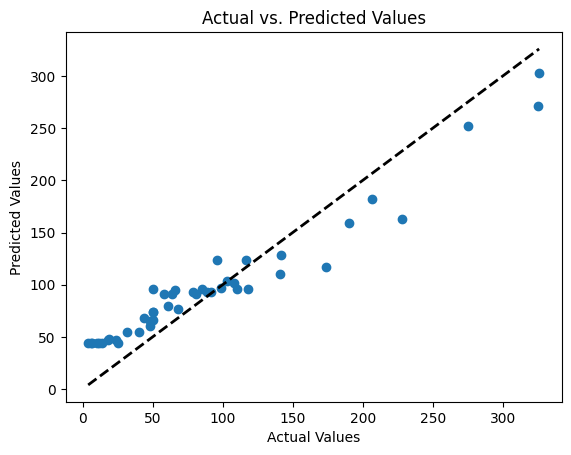

In [14]:
# TODO: langchain을 통해 생성된 코드 입력 (필요시 수정)
# Langchain이 생성한 코드 중 X_train, y_train, X_test, y_test 변수에 새로운 값을 할당하는 코드는 입력하지 말아주세요
import numpy as np
import matplotlib.pyplot as plt

# 모델의 출력값
y_pred = model.predict(X_test)

# 그래프로 시각화
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', lw=2)  # 일치하는 직선
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.show()

### 의사 결정 나무 (Decision Tree)

---

#### 회귀 모델 학습 - Decision Tree

Decision Tree 모델을 학습시켜보겠습니다.

In [15]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Decision Tree 회귀 모델 정의
model = DecisionTreeRegressor()

# 모델 학습
model.fit(X_train, y_train)

# 예측
y_pred = model.predict(X_test)

# 결정 계수 계산
r2 = r2_score(y_test, y_pred)

# 평균 제곱근 오차 계산
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("결정 계수:", r2)
print("평균 제곱근 오차:", rmse)

결정 계수: 0.8736774983493031
평균 제곱근 오차: 28.18115997928009


평가를 마친 이후, 시각화 코드를 통해 실제값과 예측값의 차이를 확인해봅시다. 

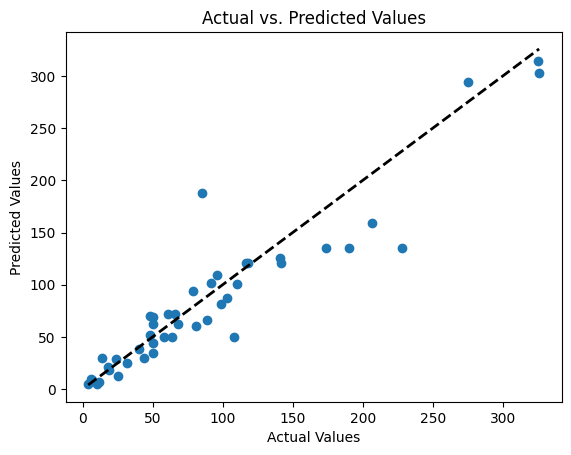

In [16]:
# TODO: langchain을 통해 생성된 코드 입력 (필요시 수정)
# Langchain이 생성한 코드 중 X_train, y_train, X_test, y_test 변수에 새로운 값을 할당하는 코드는 입력하지 말아주세요
import numpy as np
import matplotlib.pyplot as plt

# 모델의 출력값
y_pred = model.predict(X_test)

# 그래프로 시각화
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', lw=2)  # 일치하는 직선
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.show()

### 랜덤 포레스트 (RandomForest)

---

**랜덤포레스트** : 분류, 회귀 분석 등에 사용되는 앙상블 학습 방법의 일종으로, 훈련 과정에서 구성한 다수의 결정 트리로부터 분류 또는 회귀 분석을 수행

#### 회귀 모델 학습 - RandomForest

RandomForest 모델을 학습시켜보겠습니다. 

In [17]:
# TODO: langchain을 통해 생성된 코드 입력 (필요시 수정)
# Langchain이 생성한 코드 중 X_train, y_train, X_test, y_test 변수에 새로운 값을 할당하는 코드는 입력하지 말아주세요
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Random Forest 회귀 모델 정의
model = RandomForestRegressor()

# 모델 학습
model.fit(X_train, y_train)

# 예측
y_pred = model.predict(X_test)

# 결정 계수 계산
r2 = r2_score(y_test, y_pred)

# 평균 제곱근 오차 계산
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("결정 계수:", r2)
print("평균 제곱근 오차:", rmse)

결정 계수: 0.9434641462962885
평균 제곱근 오차: 18.853000704279292


평가를 마친 이후, 시각화 코드를 통해 실제값과 예측값의 차이를 확인해봅시다.

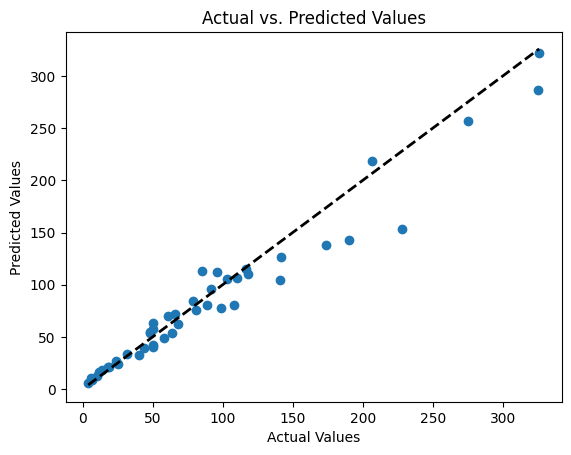

In [18]:
# TODO: langchain을 통해 생성된 코드 입력 (필요시 수정)
# Langchain이 생성한 코드 중 X_train, y_train, X_test, y_test 변수에 새로운 값을 할당하는 코드는 입력하지 말아주세요
import numpy as np
import matplotlib.pyplot as plt

# 모델의 출력값
y_pred = model.predict(X_test)

# 그래프로 시각화
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', lw=2)  # 일치하는 직선
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.show()